# 02 - EDA Estadistico (Students, columnas en espanol)

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'data').exists() and (p / 'reports').exists():
            return p
    raise RuntimeError('No se encontro la raiz del proyecto')

ROOT = find_project_root(Path.cwd().resolve())
print('Project root:', ROOT)

Project root: /home/raul/Documents/courses/unsa/machine-learning


In [14]:
path = ROOT / 'data/processed/students/students_limpio.csv'
fig_dir = ROOT / 'reports/students/figures'
fig_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(path)
print('Shape:', df.shape)
print('Nulos:', int(df.isna().sum().sum()))
df.head(2)

Shape: (1194, 31)
Nulos: 2


,anio_admision_universidad,sexo,edad,anio_aprobacion_hsc,programa,semestre_actual,tiene_beca_merito,usa_transporte_universidad,horas_estudio_diario,veces_estudio_por_dia,...,area_interes,estado_relacion,participa_actividades_cocurriculares,convivencia,tiene_problemas_salud,sgpa_previo,tiene_discapacidad_fisica,cgpa_actual,creditos_completados,ingreso_familiar_mensual
0,2018,Male,24,2016,BCSE,12,Yes,No,3,2,...,Data Schince,Single,Yes,Bachelor,No,2.68,No,3.15,75,25000
1,2021,Male,22,2020,BCSE,4,Yes,Yes,3,2,...,Event management,Single,Yes,Family,No,2.68,No,3.15,36,100000


In [15]:
print(df[['edad', 'cgpa_actual', 'sgpa_previo', 'asistencia_promedio_clase']].describe())
print('Distribucion de sexo:')
print(df['sexo'].value_counts(dropna=False))
print('Distribucion de probation:')
print(df['alguna_vez_probation'].value_counts(dropna=False))

              edad  cgpa_actual  sgpa_previo  asistencia_promedio_clase
count  1194.000000  1194.000000  1194.000000                1193.000000
mean     21.343384     3.165603     2.683945                  88.251467
std       1.613338     0.750132     0.871592                  15.319105
min      18.000000     0.000000     0.000000                   0.000000
25%      20.000000     2.900000     2.200000                  80.000000
50%      21.000000     3.210000     2.680000                  93.000000
75%      22.000000     3.670000     3.380000                 100.000000
max      27.000000     4.000000     4.000000                 100.000000
Distribucion de sexo:
sexo
Male      672
Female    522
Name: count, dtype: int64
Distribucion de probation:
alguna_vez_probation
No     896
Yes    298
Name: count, dtype: int64


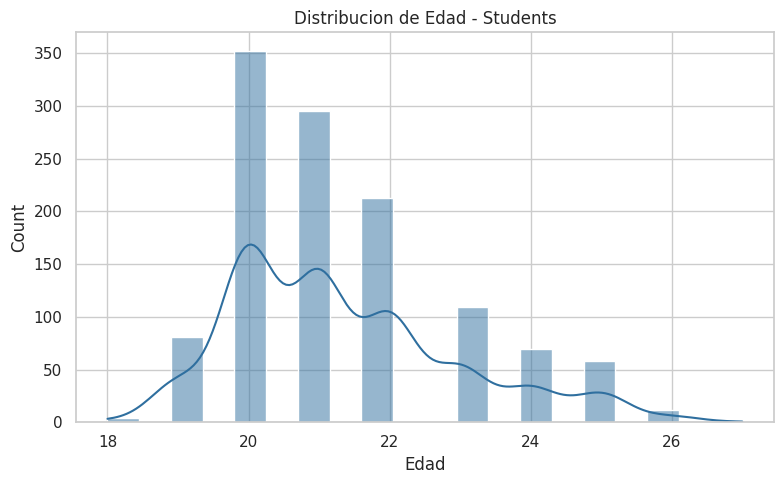

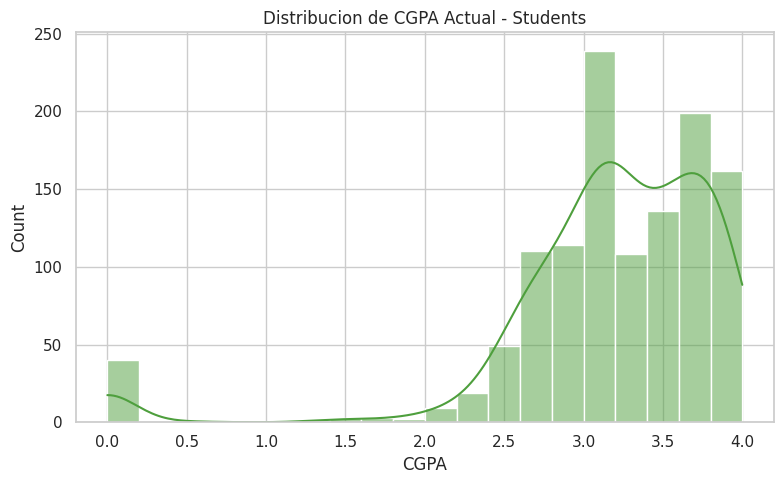

In [16]:
sns.set_theme(style='whitegrid')

plt.figure(figsize=(8,5))
sns.histplot(df['edad'].dropna(), bins=20, kde=True, color='#2f6f9f')
plt.title('Distribucion de Edad - Students')
plt.xlabel('Edad')
plt.tight_layout()
plt.savefig(fig_dir / '01_histograma_edad_students.png', dpi=150)
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df['cgpa_actual'].dropna(), bins=20, kde=True, color='#4e9f3d')
plt.title('Distribucion de CGPA Actual - Students')
plt.xlabel('CGPA')
plt.tight_layout()
plt.savefig(fig_dir / '02_histograma_cgpa_students.png', dpi=150)
plt.show()

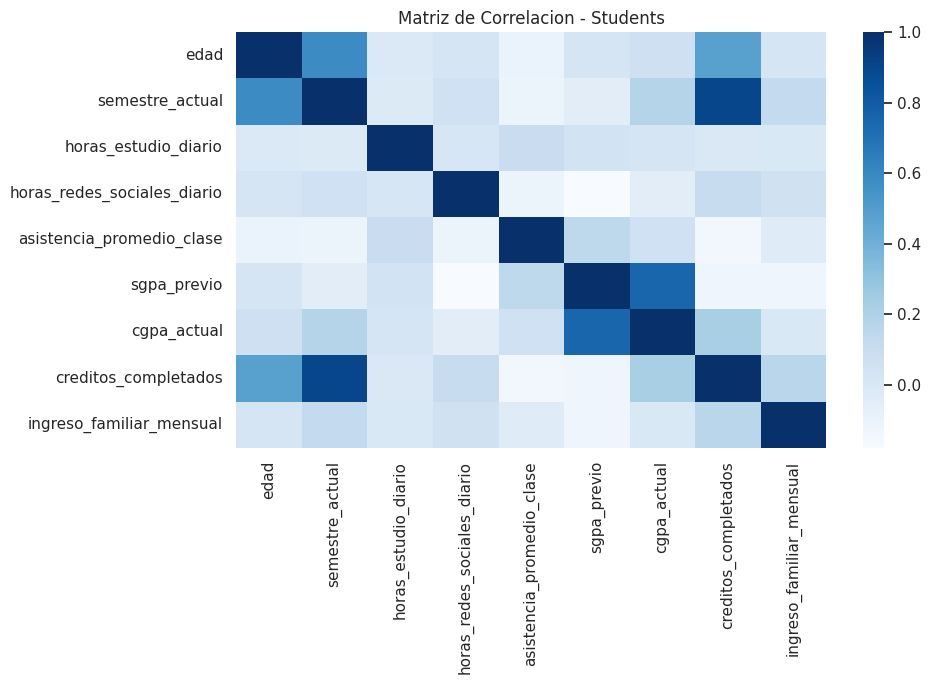

In [17]:
num_cols = [
    'edad','semestre_actual','horas_estudio_diario','horas_redes_sociales_diario',
    'asistencia_promedio_clase','sgpa_previo','cgpa_actual',
    'creditos_completados','ingreso_familiar_mensual'
]
num_cols = [c for c in num_cols if c in df.columns]

plt.figure(figsize=(10,7))
sns.heatmap(df[num_cols].corr(numeric_only=True), cmap='Blues', annot=False)
plt.title('Matriz de Correlacion - Students')
plt.tight_layout()
plt.savefig(fig_dir / '03_matriz_correlacion_students.png', dpi=150)
plt.show()